In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [ ]:
# Loading all datasets 
df = pd.read_csv('olist_order_items.csv')
df1 = pd.read_csv('olist_customers.csv')
df3 = pd.read_csv('olist_order_payments.csv')
df4 = pd.read_csv('olist_orders.csv')
df5 = pd.read_csv('olist_products.csv')
df6 = pd.read_csv('olist_sellers.csv')
df7 = pd.read_csv('olist_order_reviews.csv')
df8 = pd.read_csv('product_category_name.csv')

In [ ]:
# Loding the customers dataset 
df1

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [100]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [102]:
df1.shape[0]
df1['customer_id'].nunique()

99441

In [105]:
df1['customer_unique_id'].nunique()

96096

In [103]:
df1.groupby('customer_unique_id').size().sort_values(ascending=False).head(10)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
12f5d6e1cbf93dafd9dcc19095df0b3d     6
de34b16117594161a6a89c50b289d35a     6
63cfc61cee11cbe306bff5857d00bfe4     6
f0e310a6839dce9de1638e0fe5ab282a     6
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
dtype: int64

In [106]:
customers_by_state = (df1['customer_state'].value_counts())
customers_by_state.head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

<Axes: xlabel='customer_state'>

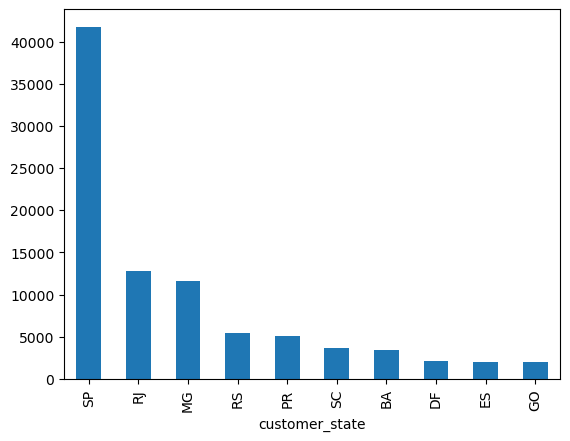

In [107]:
customers_by_state.head(10).plot(kind='bar')

In [108]:
(df1['customer_unique_id'].value_counts() > 1).sum()

np.int64(2997)

# Customers Dataset Analysis

## Dataset Overview
The customers dataset contains customer identification and geographic information.

## Data Quality
- No missing values found.
- customer_id is unique.

## Customer Identification
- customer_unique_id represents the actual customer.
- Some customers appear multiple times, indicating repeat purchases.

## Geographic Analysis
- Customers are distributed across multiple Brazilian states.
- Customer concentration is highest in a small number of regions.

## Key Insights
1 Customer records are complete.
2 customer_unique_id is the preferred customer identifier for customer-level analysis.
3 Customer distribution is uneven across states.
4 Around 96k  customers appear to purchase only once.

## 2 Analysis of Olist orders 

In [ ]:
# Loading the olist orders dataset 
df4 

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_diff,approval_hours
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,0.178333
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,30.713889
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,0.276111
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,0.298056
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,1.030556
...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,8.0,-11.0,0.000000
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,22.0,-2.0,0.194167
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,24.0,-6.0,0.292500
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,17.0,-21.0,0.131667


In [55]:
df4.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
delivery_days                    2965
delivery_diff                    2965
approval_hours                    160
dtype: int64

In [13]:
df4.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [184]:
df4['order_purchase_timestamp'] = pd.to_datetime(df4['order_purchase_timestamp'])
df4['order_approved_at'] = pd.to_datetime(df4['order_approved_at'])
df4['order_delivered_carrier_date'] = pd.to_datetime(df4['order_delivered_carrier_date'])
df4['order_delivered_customer_date'] = pd.to_datetime(df4['order_delivered_customer_date'])
df4['order_estimated_delivery_date'] = pd.to_datetime(df4['order_estimated_delivery_date'])


In [15]:
df4.duplicated().sum()

np.int64(0)

In [ ]:
# Checking Order Status 
df4['order_status'].value_counts(normalize=True)*100

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

In [186]:
# Delivery Time
df4['delivery_days'] = ( df4['order_delivered_customer_date'] - df4['order_purchase_timestamp']
).dt.days

In [187]:
df4['delivery_days'].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [188]:
# Early vs Late Delivery

df4['delivery_diff'] = ( df4['order_delivered_customer_date'] - df4['order_estimated_delivery_date']
).dt.days

In [189]:
late_delevery = (df4['delivery_diff'] > 0).mean()*100

In [32]:
(df4['delivery_diff'] < 0).mean()*100

np.float64(89.14733359479492)

In [44]:
# Approval Speed
df4['approval_hours'] = (df4['order_approved_at']- df4['order_purchase_timestamp']
).dt.total_seconds()/3600

In [ ]:
within_1_hour = (df4['approval_hours'] <= 1).mean() * 100

print(within_1_hour)

63.781538801902634


In [53]:
within_1_hour = (df4['approval_hours'] >= 5).mean() * 100

print(within_1_hour)

30.329542140565763


In [50]:
df4['approval_hours'].median()


0.3433333333333333

In [51]:
df4['approval_hours'].mean()


np.float64(10.419094301919692)

In [ ]:
# Time by which 95% of orders are approved == within 2 days 
df4['approval_hours'].quantile(0.95)

np.float64(48.46361111111111)

In [ ]:
# Seller Dispatch Performance
df4['dispatch_days'] = (df4['order_delivered_carrier_date']- df4['order_approved_at']
).dt.days

print(df4['dispatch_days'].median())

1.0


In [ ]:
# Monthly Order Count

df4['month'] = df4['order_purchase_timestamp'].dt.to_period('M')
df4.groupby('month')['order_id'].count()

month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: order_id, dtype: int64

In [ ]:
# Days of the Week with Most Orders 
df4['weekday'] = df4['order_purchase_timestamp'].dt.day_name()
df4['weekday'].value_counts()

weekday
Monday       16196
Tuesday      15963
Wednesday    15552
Thursday     14761
Friday       14122
Sunday       11960
Saturday     10887
Name: count, dtype: int64

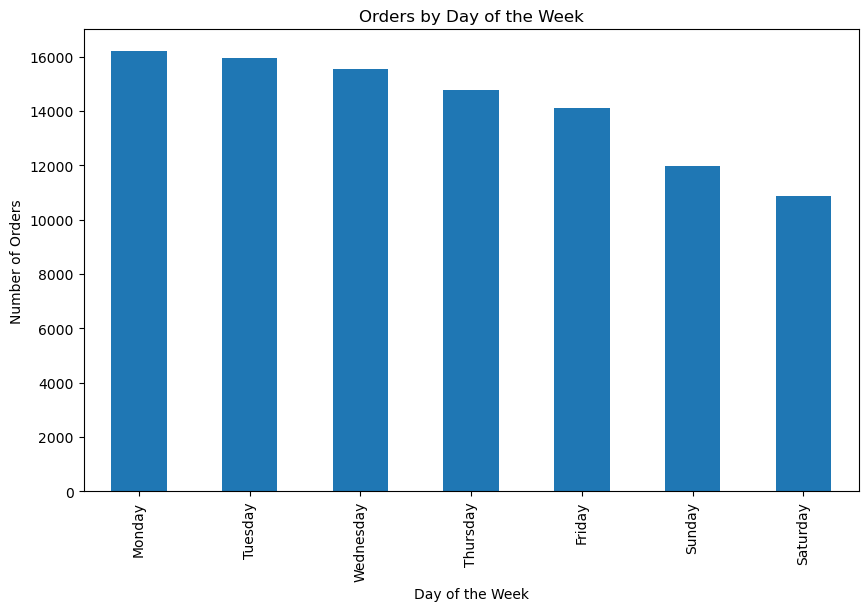

In [68]:
# plot the week days orders count
plt.figure(figsize=(10,6))
df4['weekday'].value_counts().plot(kind='bar')
plt.title('Orders by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')
plt.show()

In [71]:
df4['hour'] = df4['order_purchase_timestamp'].dt.hour
df4['hour'].value_counts().sort_index(ascending=False)

hour
23    4123
22    5816
21    6217
20    6193
19    5982
18    5769
17    6150
16    6675
15    6454
14    6569
13    6518
12    5995
11    6578
10    6177
9     4785
8     2967
7     1231
6      502
5      188
4      206
3      272
2      510
1     1170
0     2394
Name: count, dtype: int64

In [ ]:
df4.groupby( df4['order_purchase_timestamp'].dt.to_period('M')
)['delivery_days'].mean()

order_purchase_timestamp
2016-09    54.000000
2016-10    19.111111
2016-12     4.000000
2017-01    12.092000
2017-02    12.606171
2017-03    12.395522
2017-04    14.352584
2017-05    10.760508
2017-06    11.506220
2017-07    11.131198
2017-08    10.700692
2017-09    11.400723
2017-10    11.416927
2017-11    14.699506
2017-12    14.936695
2018-01    13.637290
2018-02    16.510677
2018-03    15.867485
2018-04    11.048544
2018-05    10.959105
2018-06     8.774442
2018-07     8.503736
2018-08     7.286412
2018-09          NaN
2018-10          NaN
Freq: M, Name: delivery_days, dtype: float64

In [75]:
early_delivery_rate = (df4['delivery_diff'] < 0).mean()*100
print(f"Early Delivery Rate: {early_delivery_rate:.2f}%")

Early Delivery Rate: 89.15%


## 3 analysis on olist_order_items

In [4]:
df.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [6]:
df.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [9]:
df[['order_id','order_item_id']].drop_duplicates().shape[0]

112650

In [10]:
df['price'].describe

<bound method NDFrame.describe of 0          58.90
1         239.90
2         199.00
3          12.99
4         199.90
           ...  
112645    299.99
112646    350.00
112647     99.90
112648     55.99
112649     43.00
Name: price, Length: 112650, dtype: float64>

In [40]:
df['freight_value'].describe()

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

In [ ]:
# top product by sales volume 

top_products = (df.groupby('product_id').size().sort_values(ascending=False).head(10))
top_products



product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
dtype: int64

In [24]:
top_sellers = (df.groupby('seller_id').size().sort_values(ascending=False).head(10))
top_sellers

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
dtype: int64

<Axes: >

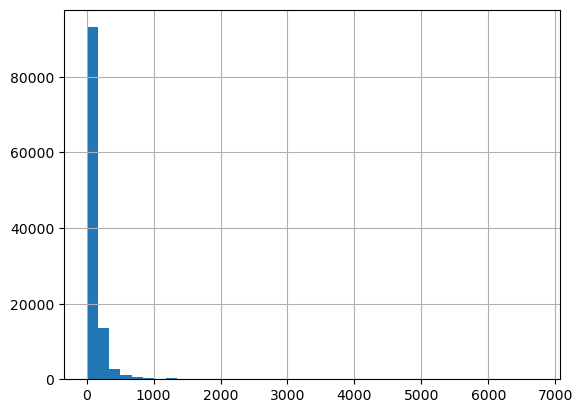

In [25]:
df['price'].hist(bins=40)

<Axes: >

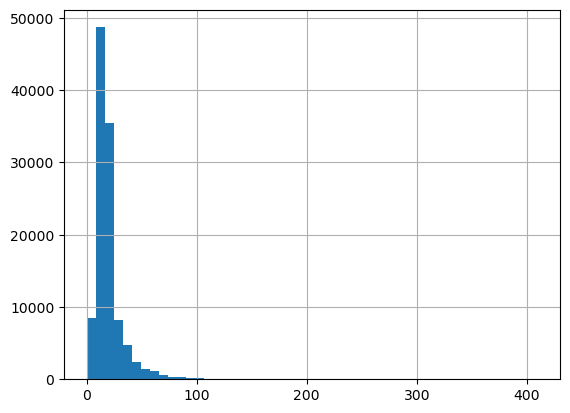

In [26]:
df['freight_value'].hist(bins=50)

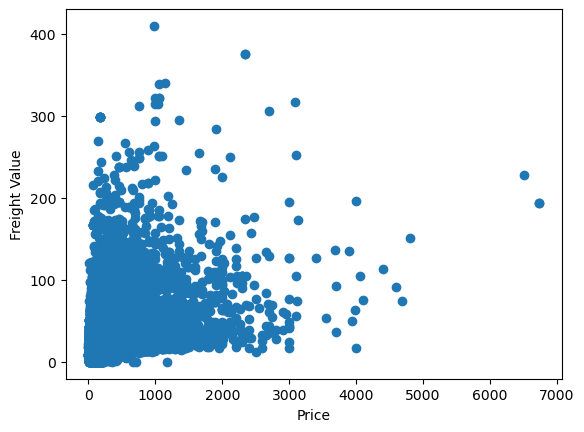

In [28]:

plt.scatter(df['price'], df['freight_value'])
plt.xlabel('Price')
plt.ylabel('Freight Value')
plt.show()

In [34]:
# 10 most expensive product 
df.nlargest(10, 'price')[['product_id', 'seller_id', 'price']]

,product_id,seller_id,price
3556,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,6735.00
112233,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,6729.00
107841,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,6499.00
74336,a6492cc69376c469ab6f61d8f44de961,59417c56835dd8e2e72f91f809cd4092,4799.00
11249,c3ed642d592594bb648ff4a04cee2747,59417c56835dd8e2e72f91f809cd4092,4690.00
62086,259037a6a41845e455183f89c5035f18,c72de06d72748d1a0dfb2125be43ba63,4590.00
29193,a1beef8f3992dbd4cd8726796aa69c53,512d298ac2a96d1931b6bd30aa21f61d,4399.87
45843,6cdf8fc1d741c76586d8b6b15e9eef30,ed4acab38528488b65a9a9c603ff024a,4099.99
78310,dd113cb02b2af9c8e5787e8f1f0722f6,821fb029fc6e495ca4f08a35d51e53a5,4059.00
59137,6902c1962dd19d540807d0ab8fade5c6,fa1c13f2614d7b5c4749cbc52fecda94,3999.90


In [35]:
df.nlargest(10, 'freight_value')[['product_id' , 'seller_id' , 'freight_value']]

,product_id,seller_id,freight_value
73486,ec31d2a17b299511e7c8627be9337b9b,257e61d3251fb5efb9daadddbc2cf7ca,409.68
3303,a3cd9517ebf5a50dca25acce54f3b171,6fa9202c10491e472dffd59a3e82b2a3,375.28
28044,a3cd9517ebf5a50dca25acce54f3b171,6fa9202c10491e472dffd59a3e82b2a3,375.28
69797,256a9c364b75753b97bee410c9491ad8,5c030029b5916fed0986310385ec9009,339.59
16731,97c948ebc8c04b26b7bbb095d4228f2a,17f51e7198701186712e53a39c564617,338.30
87936,97c948ebc8c04b26b7bbb095d4228f2a,17f51e7198701186712e53a39c564617,322.10
5037,46e24ce614899e36617e37ea1e4aa6ff,17f51e7198701186712e53a39c564617,321.88
3584,363a9f5b97bf194da23858be722a7aa5,9596c870880d900012f2e8e6e30d06d7,321.46
29787,7e53e051875b2a0c9f22acd8a9a29a20,eeb6de78f79159600292e314a77cbd18,317.47
48320,363a9f5b97bf194da23858be722a7aa5,9596c870880d900012f2e8e6e30d06d7,314.40


# Order Items Dataset Analysis

## Dataset Overview

The `order_items` dataset contains information about individual items purchased within each order. Since a single order can contain multiple products, `order_id` is not unique. The combination of `order_id` and `order_item_id` uniquely identifies each item within an order.

## Data Quality Assessment

### Missing Values
- No missing values were found in any column.
- The dataset is complete and ready for analysis.

### Uniqueness Check
- `order_id` is not unique because one order can contain multiple items.
- The combination of `order_id` and `order_item_id` forms a unique identifier for each record.
- No duplicate order-item combinations were detected.

### Data Types
- Numerical Columns:
  - `order_item_id`
  - `price`
  - `freight_value`

- Categorical Columns:
  - `order_id`
  - `product_id`
  - `seller_id`

- Date Column:
  - `shipping_limit_date`

## Price Analysis

### Findings
- Product prices show a positively skewed distribution.
- Several high-value products were identified using the IQR method.
- These observations appear to represent legitimate premium products rather than data entry errors.

### Decision
- Price outliers were retained because they reflect actual business transactions.
- Removing them would result in loss of valuable business information.

## Freight Value Analysis

### Findings
- Freight costs vary across products.
- Shipping charges are influenced by multiple factors such as product size, weight, and delivery distance.

## Relationship Between Price and Freight

### Findings
- Correlation between `price` and `freight_value`: 0.414
- This indicates a moderate positive relationship.

### Insight
- Higher-priced products tend to have higher freight costs.
- However, freight charges are also influenced by logistics-related factors and are not determined solely by product price.

## Key Insights

1. The dataset contains item-level transaction data.
2. `order_id + order_item_id` forms a unique record identifier.
3. No missing values were found.
4. Product prices are highly skewed with a small number of premium products.
5. Price outliers represent valid business transactions and were retained.
6. Freight costs vary significantly across items.
7. There is a moderate positive relationship between product price and freight charges.

## 4 Analysing the olist payment dataset

In [84]:
df3

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [85]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [86]:
df3['order_id'].nunique()

99440

In [87]:
df3.shape[0]

103886

In [88]:
payment_counts = (
    df3.groupby('order_id').size()
)

payment_counts.value_counts().sort_index()

1     96479
2      2382
3       301
4       108
5        52
6        36
7        28
8        11
9         9
10        5
11        8
12        8
13        3
14        2
15        2
19        2
21        1
22        1
26        1
29        1
Name: count, dtype: int64

In [89]:
payment_types =  df3['payment_type'].value_counts()

<Axes: xlabel='payment_type'>

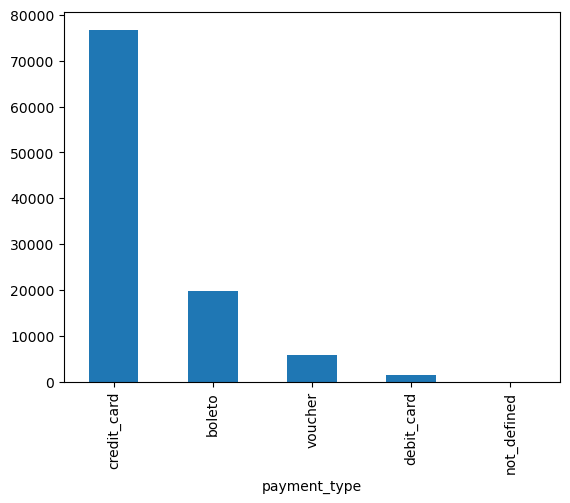

In [90]:
payment_types.plot(kind = 'bar')

In [91]:
df3['payment_value'].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

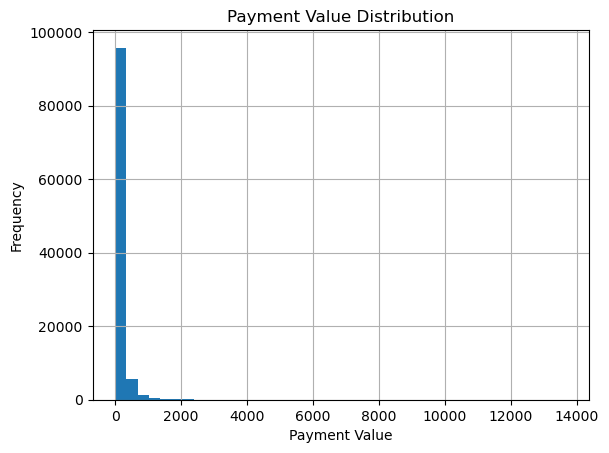

In [92]:

df3['payment_value'].hist(bins=40)
plt.title('Payment Value Distribution')
plt.xlabel('Payment Value')
plt.ylabel('Frequency')
plt.show()

In [93]:
df3['payment_installments'].describe()

count    103886.000000
mean          2.853349
std           2.687051
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64

In [94]:
df3['payment_installments'].value_counts().sort_index()

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

In [95]:
payment_valBy_type = df3.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)

<Axes: xlabel='payment_type'>

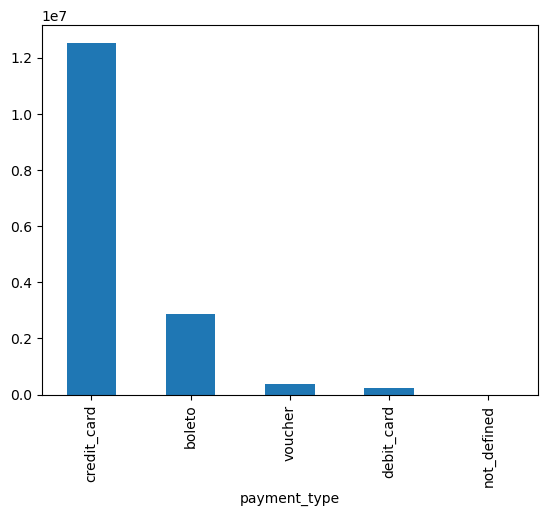

In [96]:
payment_valBy_type.plot(kind='bar')

# Insights from payment table

1 Credit card is the dominant payment method.
2 Most orders have a single payment record.
3 Some orders use multiple payment transactions.
4 Installment payments are common.
5 Payment values are right-skewed.
6 Credit cards generate the majority of payment volume.

In [195]:
df5 = pd.read_csv('olist_products.csv')

In [196]:
df5

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [197]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [198]:
df5['product_category_name'].value_counts()

product_category_name
cama_mesa_banho                  3029
esporte_lazer                    2867
moveis_decoracao                 2657
beleza_saude                     2444
utilidades_domesticas            2335
                                 ... 
fashion_roupa_infanto_juvenil       5
casa_conforto_2                     5
pc_gamer                            3
seguros_e_servicos                  2
cds_dvds_musicais                   1
Name: count, Length: 73, dtype: int64

In [199]:
df5['product_category_name'].nunique()

73

In [200]:
df5['product_category_name'].isnull().sum()

np.int64(610)

In [201]:
products_quality = df5.dropna(
    subset=['product_name_lenght','product_description_lenght','product_photos_qty']
)

In [202]:
df5['product_category_name'].isnull().sum()

np.int64(610)

In [203]:
df5['product_photos_qty'].describe()

count    32341.000000
mean         2.188986
std          1.736766
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max         20.000000
Name: product_photos_qty, dtype: float64

In [204]:
df5['product_weight_g'].describe()

count    32949.000000
mean      2276.472488
std       4282.038731
min          0.000000
25%        300.000000
50%        700.000000
75%       1900.000000
max      40425.000000
Name: product_weight_g, dtype: float64

In [205]:
df5['volume_cm3'] = (
    df5['product_length_cm']
    * df5['product_width_cm']
    * df5['product_height_cm']
)
print(df5['volume_cm3'].describe())

count     32949.000000
mean      16564.096695
std       27057.041650
min         168.000000
25%        2880.000000
50%        6840.000000
75%       18480.000000
max      296208.000000
Name: volume_cm3, dtype: float64


In [206]:
(df5['product_photos_qty']==0).sum()

np.int64(0)

In [207]:
# merging the product and order items dataframes to analyze product sales
product_sales = df.merge(df5,on='product_id')

In [208]:
product_sales

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,volume_cm3
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,3528.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,60000.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,14157.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,2400.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,42000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,53400.0
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,informatica_acessorios,31.0,232.0,1.0,8950.0,45.0,26.0,38.0,44460.0
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,esporte_lazer,43.0,869.0,1.0,967.0,21.0,24.0,19.0,9576.0
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,informatica_acessorios,56.0,1306.0,1.0,100.0,20.0,20.0,20.0,8000.0


In [209]:
most_selling = product_sales.groupby('product_category_name')['order_item_id'].count().sort_values(ascending=False)

<Axes: xlabel='product_category_name'>

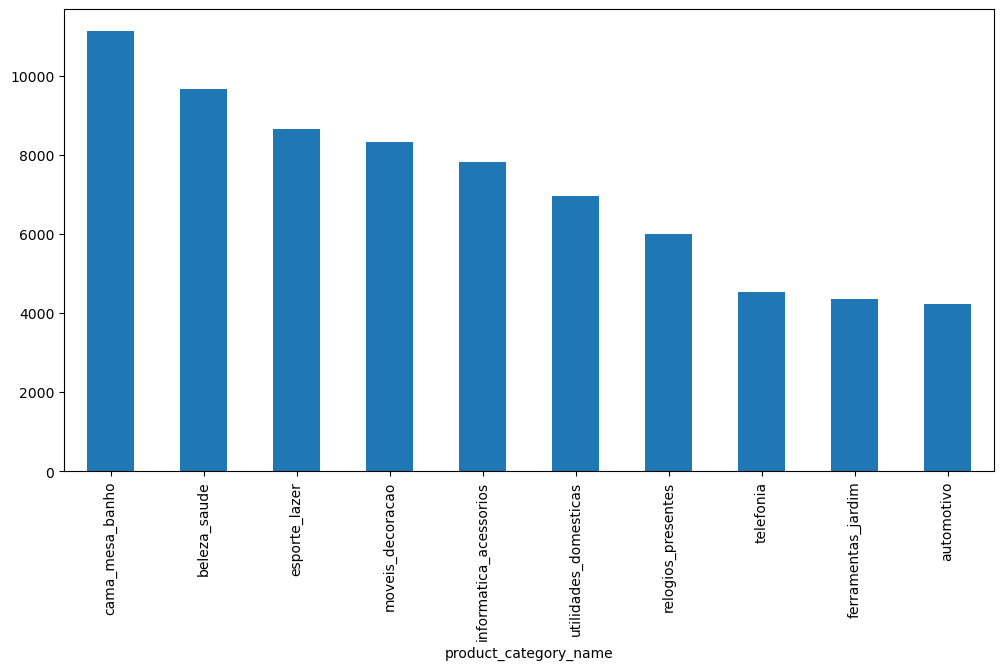

In [210]:
most_selling.head(10).plot(kind='bar', figsize=(12,6))

In [ ]:
top_revenue_products = product_sales.groupby('product_category_name')['price'].sum().sort_values(ascending=False)

<Axes: xlabel='product_category_name'>

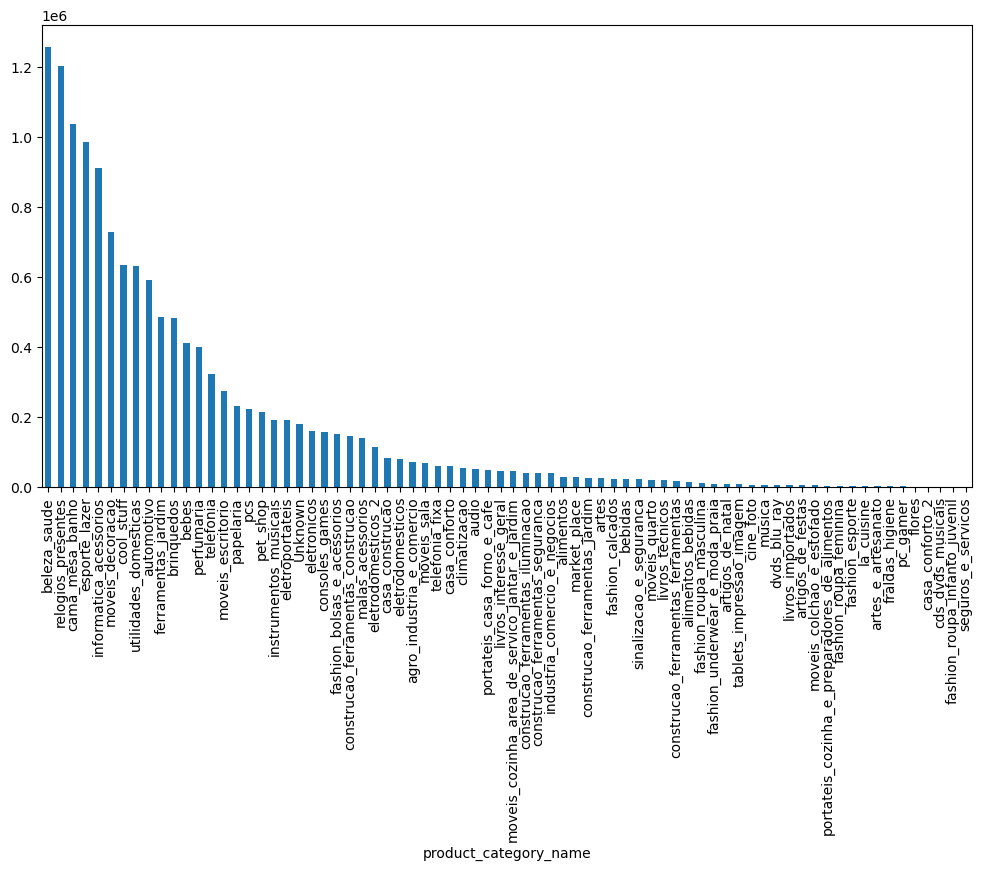

In [183]:
top_revenue_products.plot(kind='bar', figsize=(12,6))

In [211]:
product_orders = (
    df
    .merge(df5, on='product_id')
    .merge(df4, on='order_id')
)

In [215]:
late_orders = product_orders[product_orders['delivery_diff'] > 0]

late_orders.groupby(
    'product_category_name'
)['order_id'].nunique().sort_values(ascending=False)

product_category_name
cama_mesa_banho                                  689
beleza_saude                                     650
esporte_lazer                                    495
moveis_decoracao                                 449
informatica_acessorios                           417
                                                ... 
livros_importados                                  2
portateis_cozinha_e_preparadores_de_alimentos      1
flores                                             1
artes_e_artesanato                                 1
fashion_esporte                                    1
Name: order_id, Length: 66, dtype: int64

In [216]:
late_orders.groupby(
    'product_category_name'
)['delivery_diff'].mean().sort_values(ascending=False)

product_category_name
eletrodomesticos_2                               21.928571
alimentos_bebidas                                18.454545
musica                                           18.000000
moveis_colchao_e_estofado                        15.200000
sinalizacao_e_seguranca                          14.750000
                                                   ...    
fashion_roupa_feminina                            3.333333
construcao_ferramentas_jardim                     3.307692
artes                                             3.166667
portateis_cozinha_e_preparadores_de_alimentos     3.000000
cine_foto                                         3.000000
Name: delivery_diff, Length: 66, dtype: float64

## 4 Analyzing the Olist Sellers Dataset 

In [144]:
df6 

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


In [145]:
df6.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [146]:
df6.dtypes

seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object
dtype: object

In [ ]:
# total unique sellers
df6['seller_id'].nunique()

3095

In [152]:
state_wise = df6.groupby('seller_state')['seller_id'].count().sort_values(ascending=False).head(10)

Text(0.5, 1.0, 'Top 10 States by Number of Sellers')

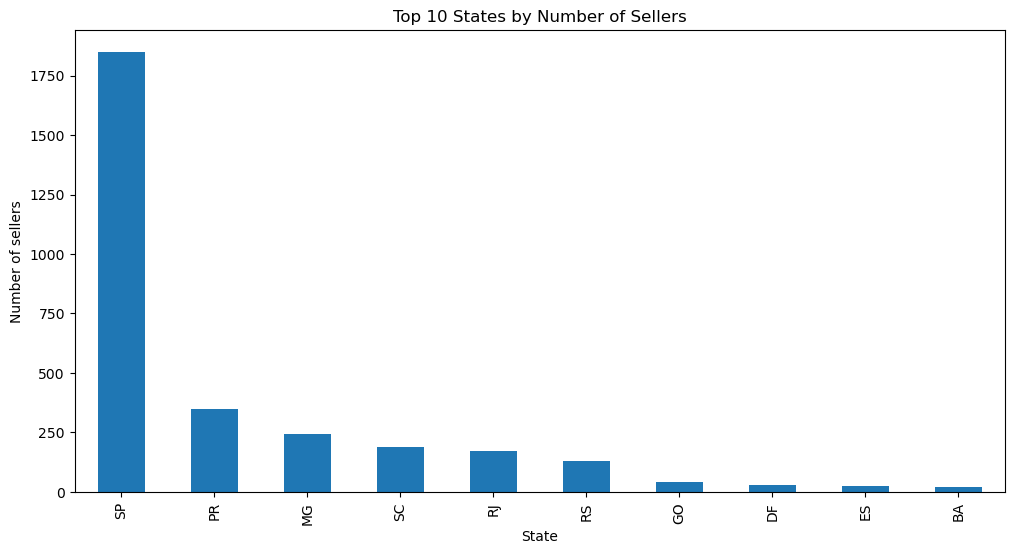

In [154]:
state_wise.plot(kind='bar', figsize=(12,6))
plt.xlabel('State')
plt.ylabel('Number of sellers')
plt.title('Top 10 States by Number of Sellers')

In [156]:
city_wise = df6.groupby('seller_city')['seller_id'].count().sort_values(ascending=False).head(10)

Text(0.5, 1.0, 'Top 10 Cities by Number of Sellers')

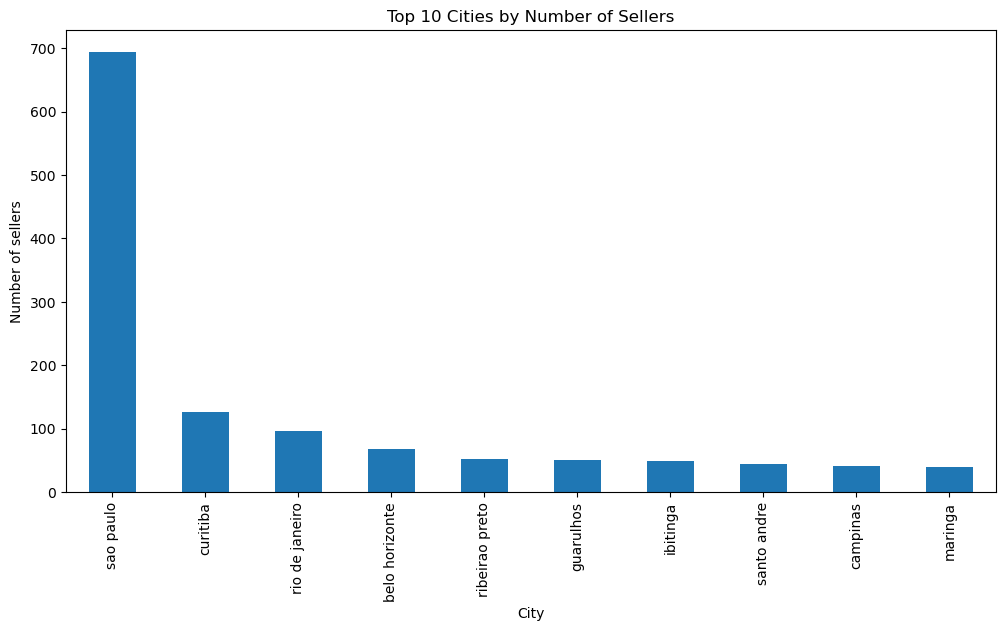

In [158]:
city_wise.plot(kind='bar', figsize=(12,6))
plt.xlabel('City')
plt.ylabel('Number of sellers')
plt.title('Top 10 Cities by Number of Sellers')

Text(0.5, 1.0, 'Top 10 Zip Code Prefixes by Number of Sellers')

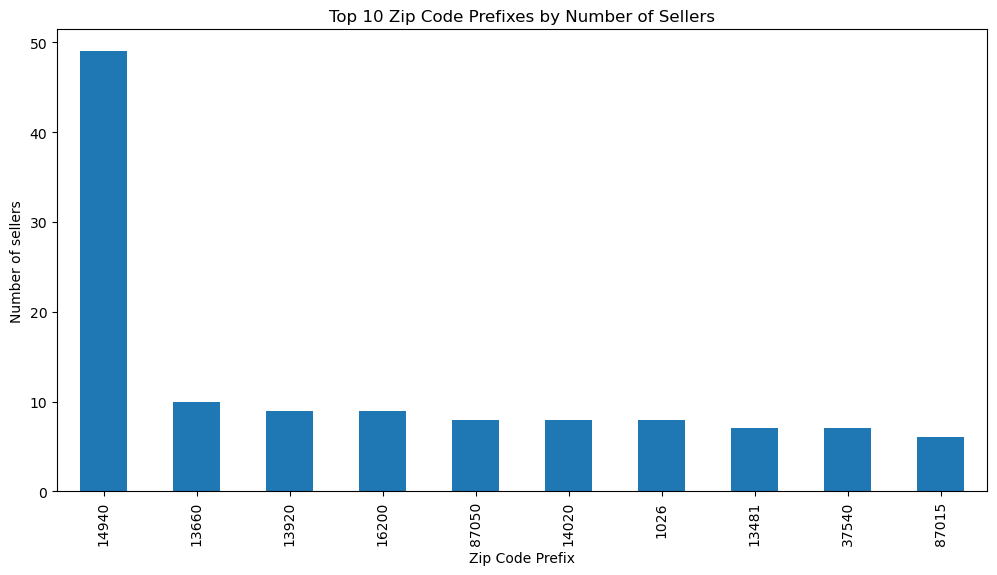

In [159]:
df6.groupby('seller_zip_code_prefix')['seller_id'].count().sort_values(ascending=False).head(10).plot(kind='bar', figsize=(12,6))
plt.xlabel('Zip Code Prefix')
plt.ylabel('Number of sellers')
plt.title('Top 10 Zip Code Prefixes by Number of Sellers')

In [161]:
seller_sales = df.merge(
    df6,
    on='seller_id'
)

In [163]:
seller_sales

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,27277,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,3471,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,37564,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,14403,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,87900,loanda,PR
...,...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,88303,itajai,SC
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,1206,sao paulo,SP
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,80610,curitiba,PR
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,4733,sao paulo,SP


In [168]:
seller_sales.groupby('seller_id')['order_item_id'].count().sort_values(ascending=False).head(10)

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
Name: order_item_id, dtype: int64

In [169]:
seller_sales.groupby('seller_id')['price'].sum().sort_values(ascending=False).head(10)

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    160236.57
7a67c85e85bb2ce8582c35f2203ad736    141745.53
1025f0e2d44d7041d6cf58b6550e0bfa    138968.55
955fee9216a65b617aa5c0531780ce60    135171.70
Name: price, dtype: float64

In [171]:
high_shiping_cost = seller_sales.groupby('seller_state')['freight_value'].mean().sort_values(ascending=False)

<Axes: xlabel='seller_state'>

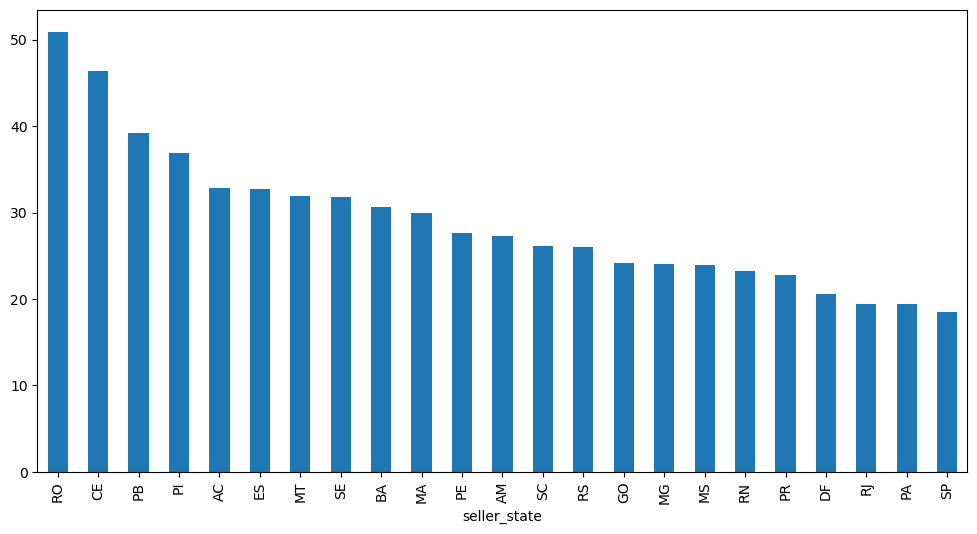

In [172]:
high_shiping_cost.plot(kind='bar', figsize=(12,6))

## Loading order Reviews 

In [218]:
df7

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [220]:
df7.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [221]:
# hey i want to fill all missing values in review comment title 
df7['review_comment_title'].fillna('N/A', inplace=True)


C:\Users\91860\AppData\Local\Temp\ipykernel_19020\784226416.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df7['review_comment_title'].fillna('N/A', inplace=True)


In [222]:
df7['review_comment_message'].fillna('N/A', inplace=True)

C:\Users\91860\AppData\Local\Temp\ipykernel_19020\1407255868.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df7['review_comment_message'].fillna('N/A', inplace=True)


In [ ]:
# merging the product, order items and order reviews dataframes to analyze product reviews
product_reviews = (
    df
    .merge(df5, on='product_id')
    .merge(df7, on='order_id')
)

In [224]:
product_reviews.groupby(
    'product_category_name'
)['review_score'].mean().sort_values(ascending=False)

product_category_name
cds_dvds_musicais                                4.642857
fashion_roupa_infanto_juvenil                    4.500000
livros_interesse_geral                           4.446266
construcao_ferramentas_ferramentas               4.444444
flores                                           4.419355
                                                   ...   
moveis_escritorio                                3.493183
pc_gamer                                         3.333333
portateis_cozinha_e_preparadores_de_alimentos    3.266667
fraldas_higiene                                  3.256410
seguros_e_servicos                               2.500000
Name: review_score, Length: 73, dtype: float64

In [225]:
product_reviews.groupby(
    'product_category_name'
)['review_score'].mean().sort_values()

product_category_name
seguros_e_servicos                               2.500000
fraldas_higiene                                  3.256410
portateis_cozinha_e_preparadores_de_alimentos    3.266667
pc_gamer                                         3.333333
moveis_escritorio                                3.493183
                                                   ...   
flores                                           4.419355
construcao_ferramentas_ferramentas               4.444444
livros_interesse_geral                           4.446266
fashion_roupa_infanto_juvenil                    4.500000
cds_dvds_musicais                                4.642857
Name: review_score, Length: 73, dtype: float64

In [226]:
product_reviews.groupby(
    'product_category_name'
)['review_id'].count().sort_values(ascending=False)

product_category_name
cama_mesa_banho                  11137
beleza_saude                      9645
esporte_lazer                     8640
moveis_decoracao                  8331
informatica_acessorios            7849
                                 ...  
cds_dvds_musicais                   14
la_cuisine                          13
pc_gamer                             9
fashion_roupa_infanto_juvenil        8
seguros_e_servicos                   2
Name: review_id, Length: 73, dtype: int64

In [227]:

product_reviews.groupby(
    'product_category_name'
).apply(
    lambda x: (x['review_score'] <= 2).mean() * 100
).sort_values(ascending=False)


C:\Users\91860\AppData\Local\Temp\ipykernel_19020\958101678.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(


product_category_name
seguros_e_servicos                               50.000000
pc_gamer                                         33.333333
portateis_cozinha_e_preparadores_de_alimentos    33.333333
fashion_roupa_masculina                          28.244275
moveis_escritorio                                26.081802
                                                   ...    
livros_interesse_geral                            8.561020
construcao_ferramentas_ferramentas                8.080808
alimentos_bebidas                                 7.885305
flores                                            6.451613
cds_dvds_musicais                                 0.000000
Length: 73, dtype: float64

In [ ]:
# convert the whole ipynb file into csv file